In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow import keras
from tensorflow.keras import layers

C:\Users\USER\anaconda3\envs\prog1\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
data = fetch_california_housing()

X = data.data
y = data.target

print("Feature-ök száma:", X.shape[1])
print("Minták száma:", X.shape[0])

Feature-ök száma: 8
Minták száma: 20640


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [5]:
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(64, activation='relu'), # relu: max(0,x)
    layers.Dense(1)
])

C:\Users\USER\anaconda3\envs\prog1\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.compile(
    optimizer='adam', # adam --> egy jobb gradiens descent algoritmus
    loss='mse',
    metrics=['mae']
)

In [7]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    verbose=1 # progress bar
)

Epoch 1/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.8017 - mae: 0.6184 - val_loss: 0.4658 - val_mae: 0.4730
Epoch 2/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4077 - mae: 0.4517 - val_loss: 0.4124 - val_mae: 0.4536
Epoch 3/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3736 - mae: 0.4344 - val_loss: 0.3955 - val_mae: 0.4447
Epoch 4/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3685 - mae: 0.4253 - val_loss: 0.3847 - val_mae: 0.4353
Epoch 5/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3587 - mae: 0.4183 - val_loss: 0.4105 - val_mae: 0.4423
Epoch 6/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4060 - mae: 0.4145 - val_loss: 0.3736 - val_mae: 0.4255
Epoch 7/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3336 - mae: 0.4040 - val_loss: 0.3523 - val_mae: 0.4095
Epoch 8/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3247 - mae: 0.3987 - val_loss: 0.3648 - val_mae: 0.4112
Epoch 9/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - lo

In [8]:
test_loss, test_mae = model.evaluate(X_test, y_test)

print("Teszt MAE:", test_mae)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2770 - mae: 0.3623
Teszt MAE: 0.3622783422470093


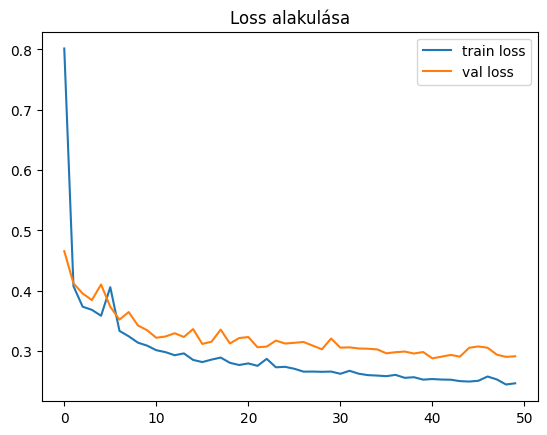

In [9]:
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss alakulása")
plt.show()

In [10]:
preds = model.predict(X_test[:5])

for i in range(5):
    print(f"Predikció: {preds[i][0]:.2f}, Valós: {y_test[i]:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Predikció: 0.49, Valós: 0.48
Predikció: 0.83, Valós: 0.46
Predikció: 4.83, Valós: 5.00
Predikció: 2.46, Valós: 2.19
Predikció: 2.73, Valós: 2.78
